In [1]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/

In [2]:
IMG_HEIGHT = 100
IMG_WIDTH = 100
BATCH_SIZE = 32
NUM_CLASSES = 4

In [3]:
DATASET_DIR = "../Final"

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 1451 images belonging to 4 classes.


In [6]:
val_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 361 images belonging to 4 classes.


In [7]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

In [8]:
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze ONLY last 20 layers
for layer in base_model.layers[-20:]:
    layer.trainable = True

In [9]:
model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

In [10]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,782,660 (105.98 MB)

 Trainable params: 13,126,276 (50.07 MB)

 Non-trainable params: 14,656,384 (55.91 MB)

In [12]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_labels = list(train_generator.class_indices.keys())
print("Classes:", class_labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)

Classes: ['Good', 'Moderate', 'Severe', 'Unhealthy']
Class weights: {0: np.float64(25.910714285714285), 1: np.float64(0.9253826530612245), 2: np.float64(1.8413705583756346), 3: np.float64(0.42777122641509435)}


In [13]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict
)

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.3177 - loss: 1.8418 - val_accuracy: 0.0083 - val_loss: 1.6297
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.3067 - loss: 1.3731 - val_accuracy: 0.0083 - val_loss: 1.6040
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.2102 - loss: 1.4008 - val_accuracy: 0.0083 - val_loss: 1.4482
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.1234 - loss: 1.3807 - val_accuracy: 0.0083 - val_loss: 1.4134
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.1440 - loss: 1.3919 - val_accuracy: 0.3213 - val_loss: 1.3848
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 45s 967ms/step - accuracy: 0.1909 - loss: 1.3739 - val_accuracy: 0.2715 - val_loss: 1.4204
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 44s 954ms/step - accuracy: 0.2943 - loss: 1.3752 - val_accuracy: 0.3158 - val_loss: 1.4165
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 46s 996ms/step - accuracy: 0.5562 - loss: 1.3642 - val_accuracy: 0.3213 - 

In [14]:
print("Class indices:", train_generator.class_indices)

from collections import Counter
print("Train distribution:", Counter(train_generator.classes))
print("Validation distribution:", Counter(val_generator.classes))

Class indices: {'Good': 0, 'Moderate': 1, 'Severe': 2, 'Unhealthy': 3}
Train distribution: Counter({np.int32(3): 848, np.int32(1): 392, np.int32(2): 197, np.int32(0): 14})
Validation distribution: Counter({np.int32(3): 211, np.int32(1): 98, np.int32(2): 49, np.int32(0): 3})


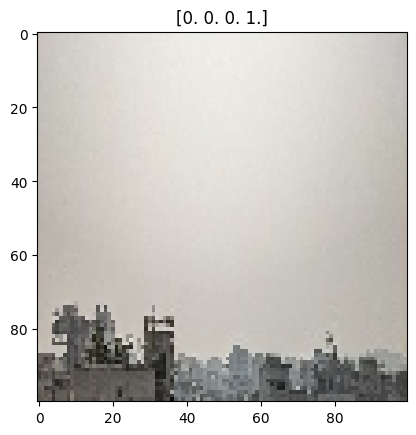

In [15]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.imshow(images[0])
plt.title(labels[0])
plt.show()

In [16]:
model.save("aqi_model_class_weighted.h5")
print("Model saved successfully (H5 format)")

Model saved successfully (H5 format)


In [17]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

model = load_model("aqi_model_class_weighted.h5")

img_path = "../test/Test Image.jpg"

img = image.load_img(img_path, target_size=(100, 100))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

class_names = ["Good", "Moderate", "Unhealthy", "Very Unhealthy"]

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

print("Predicted AQI class:", class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted AQI class: Moderate


In [18]:
model.input_shape

(None, 100, 100, 3)

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,782,662 (105.98 MB)

 Trainable params: 13,126,276 (50.07 MB)

 Non-trainable params: 14,656,384 (55.91 MB)

 Optimizer params: 2 (12.00 B)

In [20]:
train_generator.classes

array([0, 0, 0, ..., 3, 3, 3], shape=(1451,), dtype=int32)

In [21]:
from collections import Counter
Counter(train_generator.classes)

Counter({np.int32(3): 848,
         np.int32(1): 392,
         np.int32(2): 197,
         np.int32(0): 14})